In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import optuna
import pandas as pd
import plotnine as p9

In [2]:
l = list()
for approach in ['Fine-tuning', 'Fine-tuning-Truncated', 'Chefer_importance', 'Sliding_windows', 'Attention_distillation']:
  for dataset in ['IMDb-1k', 'Ohsumed', 'R8', 'SST-2']: # 'IMDb'
    for binding in ['', '-unbound']:
      study_name = f'{dataset}-{approach}{binding}'
      if not os.path.exists(f'../../optuna_studies/{study_name}.db'):
        print(f'Skipping {study_name}...')
        continue
      study = optuna.load_study(
        study_name = study_name,
        storage = f'sqlite:///../../optuna_studies/{study_name}.db'
      )
      trials_df = study.trials_dataframe()
      trials_df = trials_df[(trials_df['state'] == 'COMPLETE') & (trials_df['value'] >= 0.0)][['number', 'value']] \
        .assign(
          approach = approach,
          dataset = dataset,
          binding = binding
        )
      l.append(trials_df)
trials_df = pd.concat(l, ignore_index = True)

In [3]:
trials_df['value'] = trials_df['value'] * 100
trials_df['approach'] = trials_df['approach'].replace({
  'Fine-tuning' : 'Chunk-based\nFine-tuning', #'FT (Chunks)',
  'Fine-tuning-Truncated' : 'Fine-tuning', #'FT',
  'Chefer_importance' : 'Chefer\nImportance', #'CI',
  'Sliding_windows' : 'Sliding\nWindows', #'SW',
  'Attention_distillation' : 'Attention\nDistillation'#'AD'
})
trials_df['approach'] = pd.Categorical(trials_df['approach'], categories = ['Fine-tuning', 'Chunk-based\nFine-tuning', 'Sliding\nWindows', 'Attention\nDistillation', 'Chefer\nImportance'], ordered = True) # categories = ['FT', 'TFT', 'SW', 'AD', 'CI']
trials_df['binding'] = trials_df['binding'].replace({
  '' : 'Discrete',
  '-unbound' : 'Continuous',
})
trials_df['binding'] = pd.Categorical(trials_df['binding'], categories = ['Discrete', 'Continuous'], ordered = True)

In [4]:
# trials_df.groupby(by = ['dataset', 'approach', 'binding']).size()

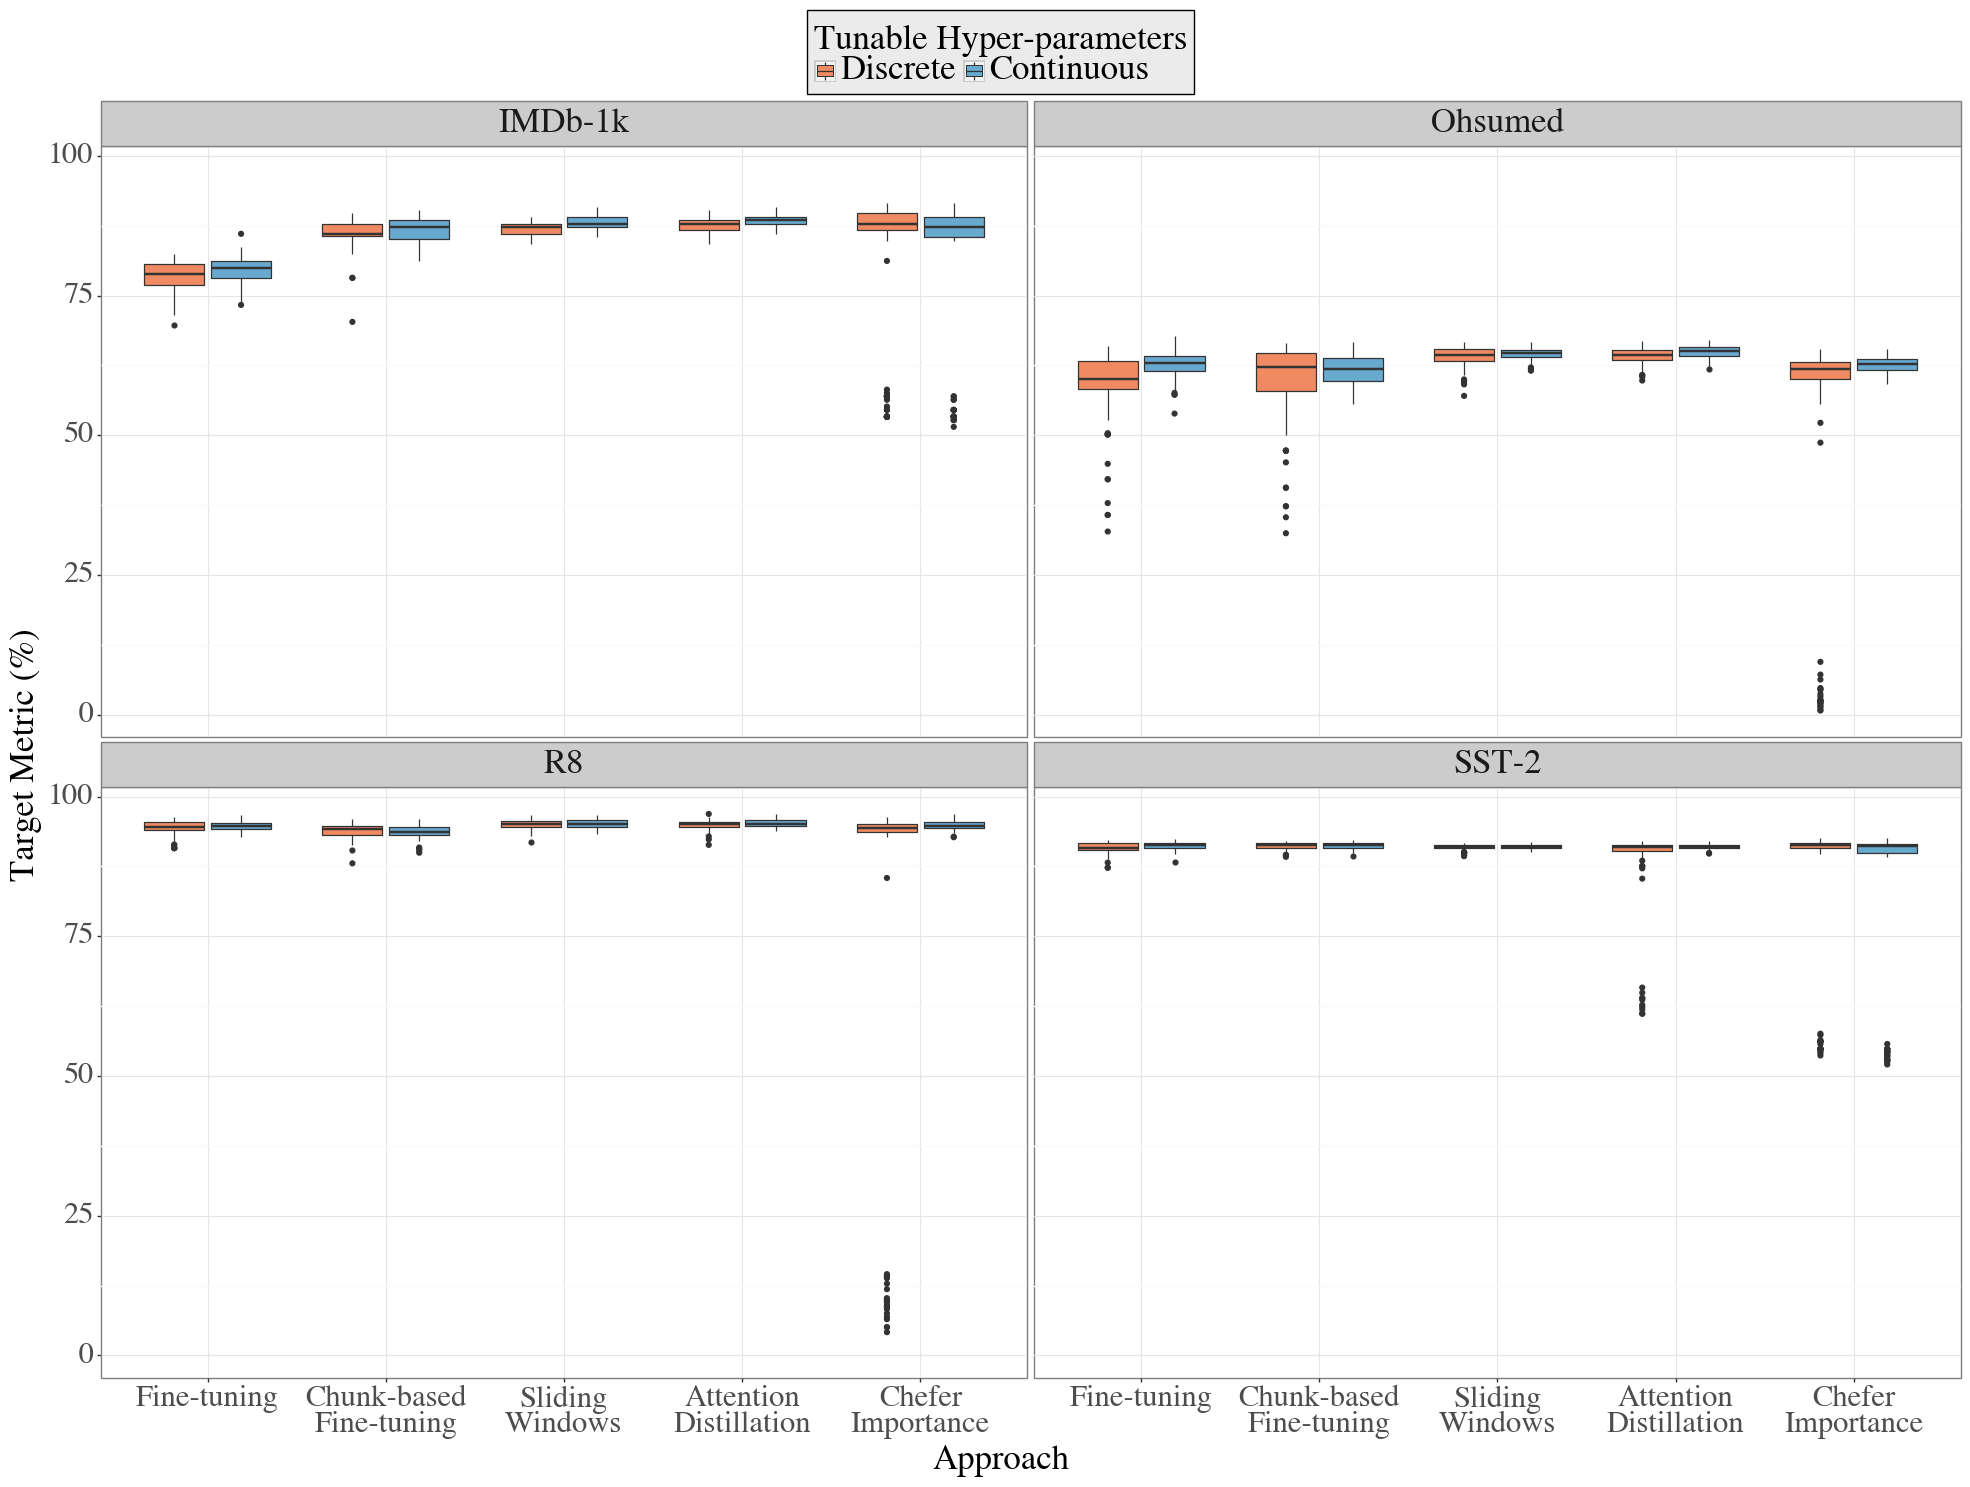

<ggplot: (333365083)>

In [5]:
p9.ggplot(
    trials_df,
    p9.aes(x = 'approach', y = 'value', fill = 'binding')
  ) + \
    p9.geom_boxplot() + \
    p9.xlab('Approach') + \
    p9.ylab('Target Metric (%)') + \
    p9.labs(fill = 'Tunable Hyper-parameters') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [6]:
aggregated_trials_df = trials_df.groupby(by = ['dataset', 'binding', 'approach']).agg({'value' : ['mean', 'std']}).reset_index()
aggregated_trials_df.columns = aggregated_trials_df.columns.map('_'.join).str.strip('_')
aggregated_trials_df['label'] = aggregated_trials_df['value_mean'].round(2).astype(str) + ' ± ' + aggregated_trials_df['value_std'].round(2).astype(str)

In [7]:
plot = p9.ggplot(
    aggregated_trials_df,
    p9.aes(x = 'approach', y = 'value_mean', fill = 'binding')
  ) + \
    p9.geom_bar(stat = 'identity', position = p9.position_dodge2(), colour = '#000000') + \
    p9.geom_errorbar(p9.aes(ymin = 'value_mean - value_std', ymax = 'value_mean + value_std'), position = p9.position_dodge(width = .9), width = .4, size = .85) + \
    p9.geom_text(p9.aes(y = 'value_mean - value_std - 2.5', label = 'label'), position = p9.position_dodge2(width = .9), size = 20, angle = 90, va = 'top') + \
    p9.xlab('Approach') + \
    p9.ylab('Target Metric (%)') + \
    p9.labs(fill = 'Tunable Hyper-parameters') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2, scales = 'free_y') + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
      subplots_adjust = {
        'wspace' : 0.075
      }
    )

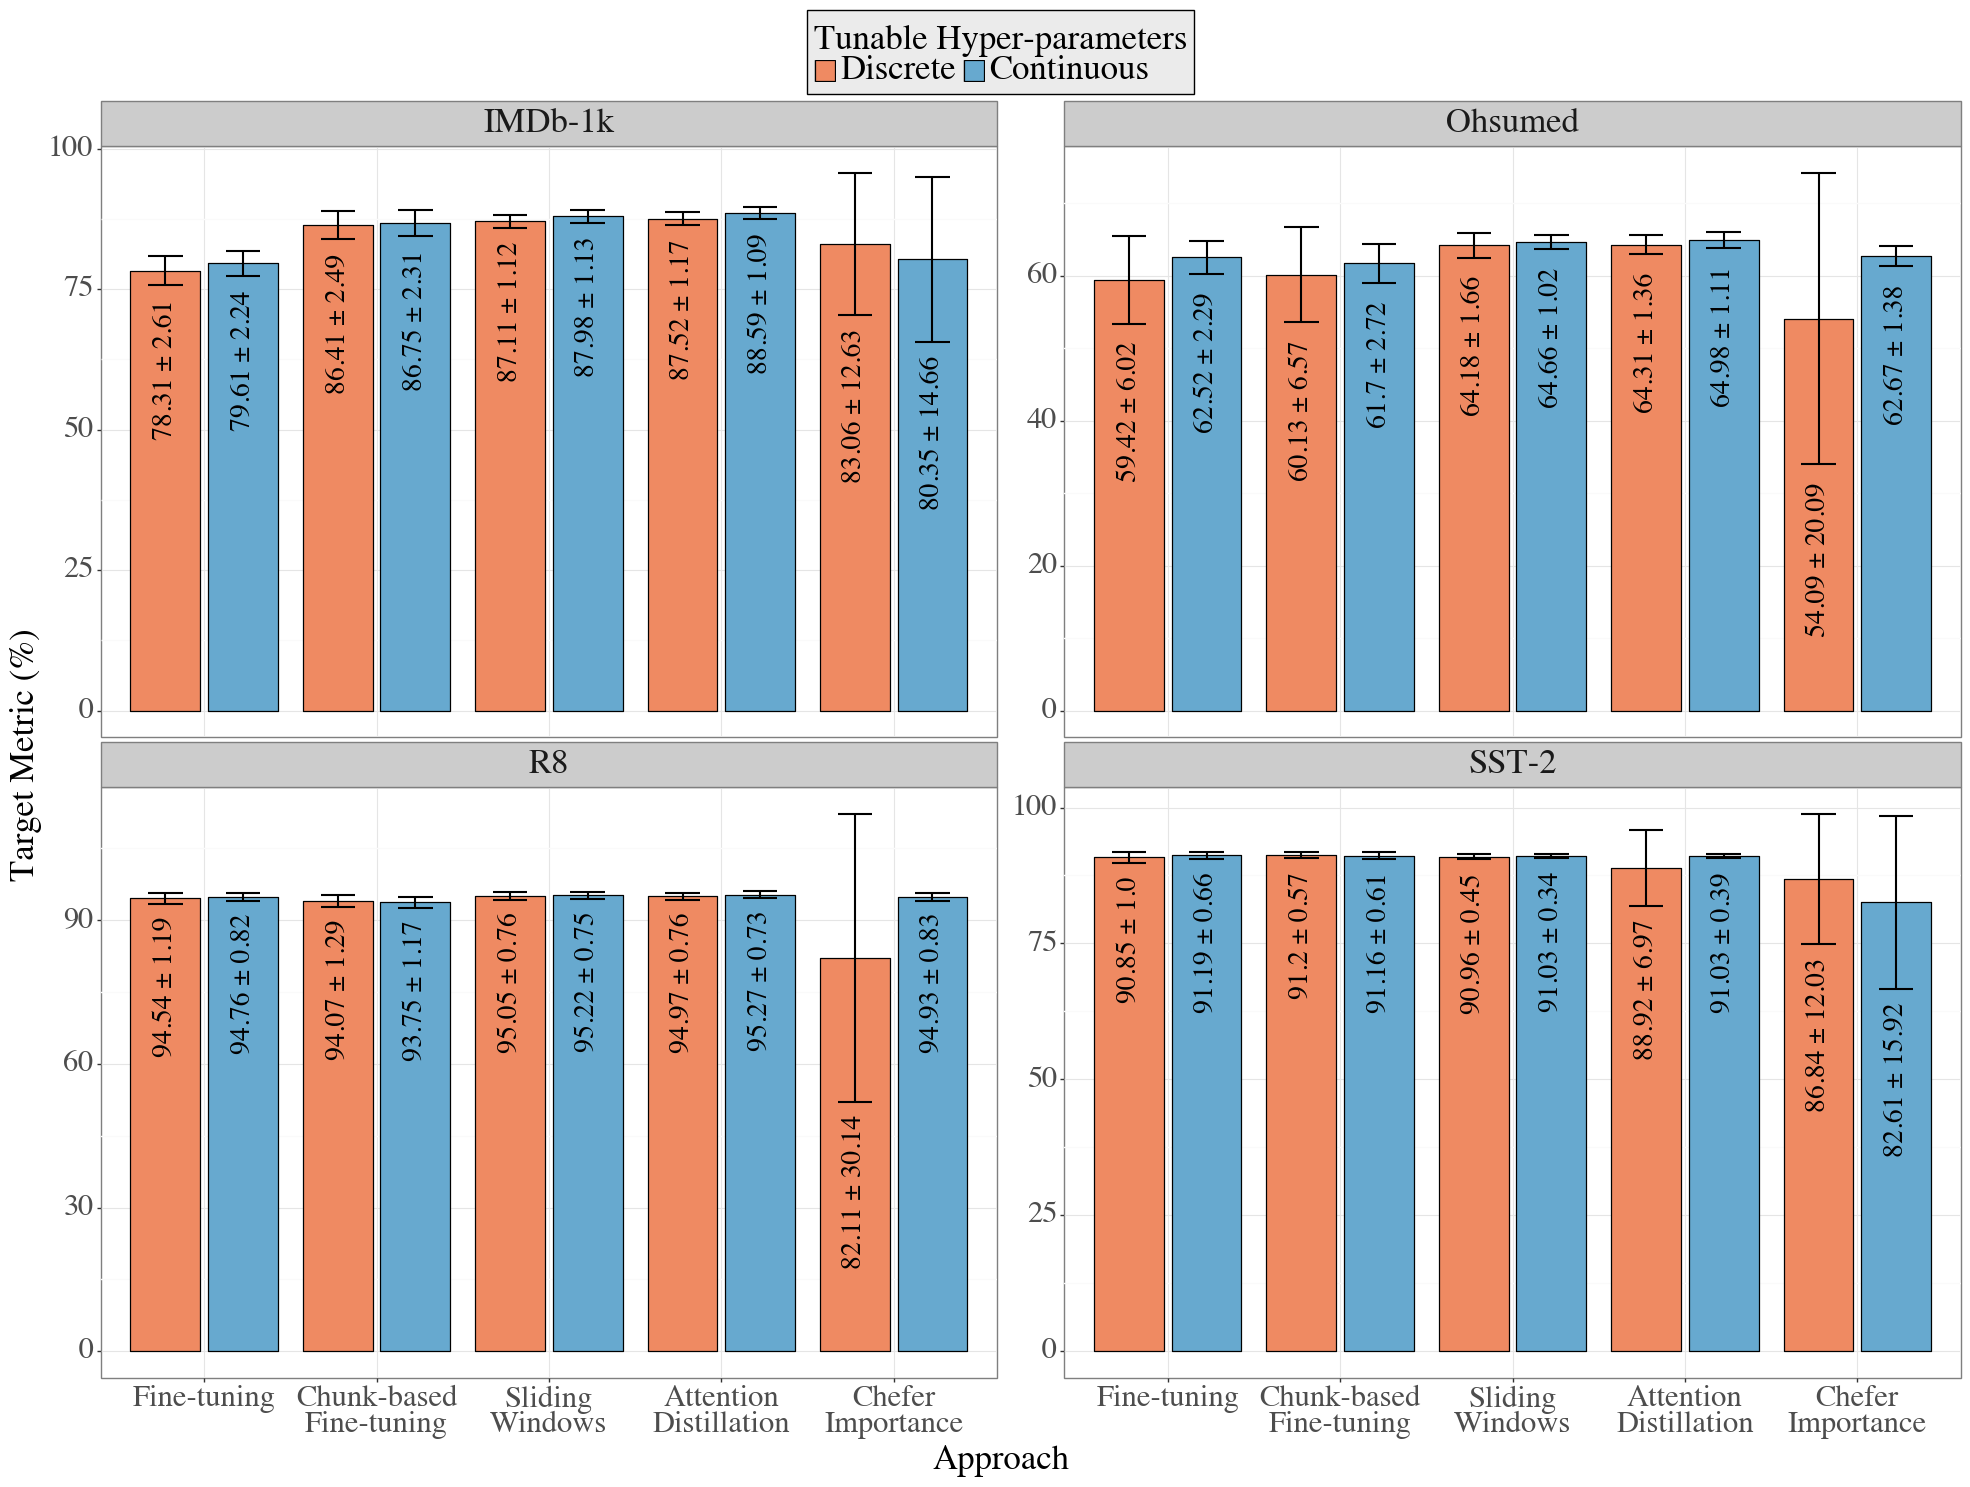

<ggplot: (333181322)>

In [8]:
plot

In [9]:
plot.save(filename = '../figures/validation_performance_instability.png', dpi = 300)